**Add your LiU-ID here:**
* sopce285
* axest556

### **Quick introduction to jupyter notebooks**
* Each cell in this notebook contains either code or text.
* You can run a cell by pressing Ctrl-Enter, or run and advance to the next cell with Shift-Enter.
* Code cells will print their output, including images, below the cell. Running it again deletes the previous output, so be careful if you want to save some results.
* You don't have to rerun all cells to test changes, just rerun the cell you have made changes to. Some exceptions might apply, for example if you overwrite variables from previous cells, but in general this will work.
* If all else fails, use the "Kernel" menu and select "Restart Kernel and Clear All Output". You can also use this menu to run all cells.
* A useful debug tool is the console. You can right-click anywhere in the notebook and select "New console for notebook". This opens a python console which shares the environment with the notebook, which let's you easily print variables or test commands.

### **Setup**

In [1]:
import os
import tensorflow as tf

# If there are multiple GPUs and we only want to use one/some, set the number in the visible device list.
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

# This sets the GPU to allocate memory only as needed
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) != 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True) 

### **1. Loading the dataset**
This assignment will focus on the CIFAR10 dataset. This is a collection of small images in 10 classes such as cars, cats, birds, etc. You can find more information here: https://www.cs.toronto.edu/~kriz/cifar.html. We start by loading and examining the data.

In [3]:
import numpy as np
from keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Shape of training data:")
print(X_train.shape)
print(y_train.shape)
print("Shape of test data:")
print(X_test.shape)
print(y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Shape of training data:
(50000, 32, 32, 3)
(50000, 1)
Shape of test data:
(10000, 32, 32, 3)
(10000, 1)


#### **<span style="color:red">Question 1:</span>**
The shape of X_train and X_test has 4 values. What do each of these represent?

#### **<span style="color:green">Answer:</span>**
* 50000/10000: The samples, each row is a separate image sample
* 32: X-coordinates of the 32x32 pixel image
* 32: Y-coordinates of the 32x32 pixel image
* 3: red/green/blue channel values

##### **Plotting some images**
This plots a random selection of images from each class. Rerun the cell to see a different selection.

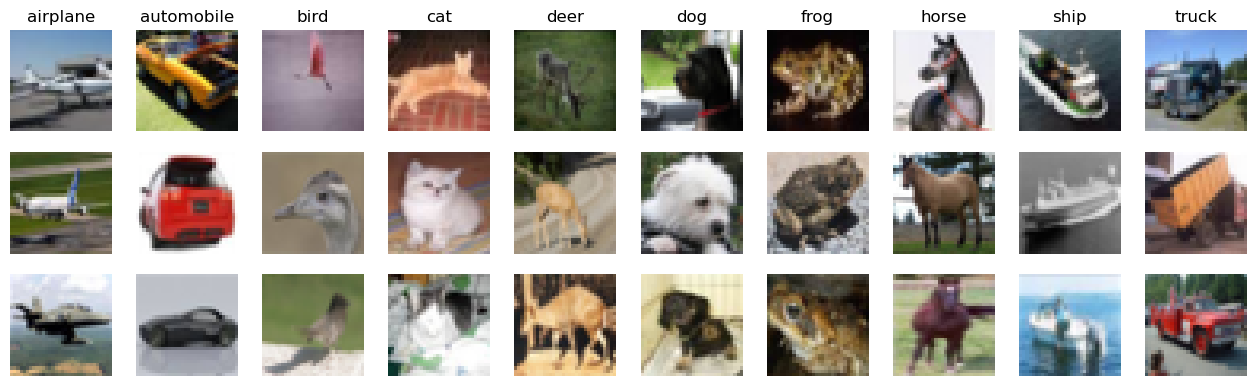

In [4]:
from Custom import PlotRandomFromEachClass

cifar_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
PlotRandomFromEachClass(X_train, y_train, 3, labels=cifar_labels)

##### **Preparing the dataset**
Just like the MNIST dataset we normalize the images to [0,1] and transform the class indices to one-hot encoded vectors.

In [6]:
from keras.utils import to_categorical

# Transform label indices to one-hot encoded vectors
y_train_c = to_categorical(y_train, num_classes=10)
y_test_c  = to_categorical(y_test , num_classes=10)

# Normalization of pixel values (to [0-1] range)
X_train = X_train.astype('float32') / 255
X_test  = X_test.astype('float32')  / 255

##### **Training and evaluating the model**
Below, we define a function that performs model training and evaluation. The first input parameter is another function that you will write, that creates and returns the model object in each task.

In order to show the differences between models in the first parts of the assignment, we will restrict the training to the following command using 15 epochs, batch size 32, and 20% validation data. From section 5 and forward you can change this as you please to increase the accuracy, but for now stick with this command.

We use ```model.evaluate``` to get the loss and metric scores on the test data. To plot the results we give you a custom function that does the work for you.

In [7]:
from Custom import PlotModelEval

def TrainModelAndPlotResults(get_model_func, epochs=15, batch_size=32):
    # Get model using function handle parameter
    model = get_model_func()

    # Build the model using Stochastic Gradient Descent with Nesterov momentum. We use accuracy as the metric.
    sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
    model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary(100)

    # Train the model and store the training history
    history = model.fit(X_train,y_train_c, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Evaluate on the test set and store the score
    score = model.evaluate(X_test, y_test_c, batch_size=128, verbose=0)

    # Print the result metrics
    print("")
    print('_' * 100)
    for i in range(len(score)):
        print("Test " + model.metrics_names[i] + " = %.3f" % score[i])
    print("")

    # Plot the training history and results
    PlotModelEval(model, history, X_test, y_test, cifar_labels)

### **2. Fully connected classifier**
We will start by creating a fully connected classifier using the ```Dense``` layer. We give you the first layer that flattens the image features to a single vector. Add the remaining layers to the network.

Consider what the size of the output must be and what activation function you should use in the output layer.

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)                 │ (None, 32, 32, 3)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ flatten_2 (Flatten)                        │ (None, 3072)                    │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_5 (Dense)                            │ (None, 64)                      │           196,672 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_6 (Dense)                            │ (None, 128)                     │             8,320 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_7 (Dense)                            │ (None, 10)                      │             1,290 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 206,282 (805.79 KB)

 Trainable params: 206,282 (805.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 921us/step - accuracy: 0.2779 - loss: 1.9585 - val_accuracy: 0.3745 - val_loss: 1.7378
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - accuracy: 0.3807 - loss: 1.7236 - val_accuracy: 0.3594 - val_loss: 1.7669
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - accuracy: 0.3991 - loss: 1.6724 - val_accuracy: 0.3995 - val_loss: 1.6863
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - accuracy: 0.4186 - loss: 1.6214 - val_accuracy: 0.4142 - val_loss: 1.6508
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - accuracy: 0.4228 - loss: 1.6073 - val_accuracy: 0.4016 - val_loss: 1.6810
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 884us/step - accuracy: 0.4300 - loss: 1.5846 - val_accuracy: 0.4208 - val_loss: 1.6121
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step - accuracy: 0.4323 - loss: 1.5736 - val_accuracy: 0.4113 - val_loss: 1.6490
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - accuracy: 0.4409 -

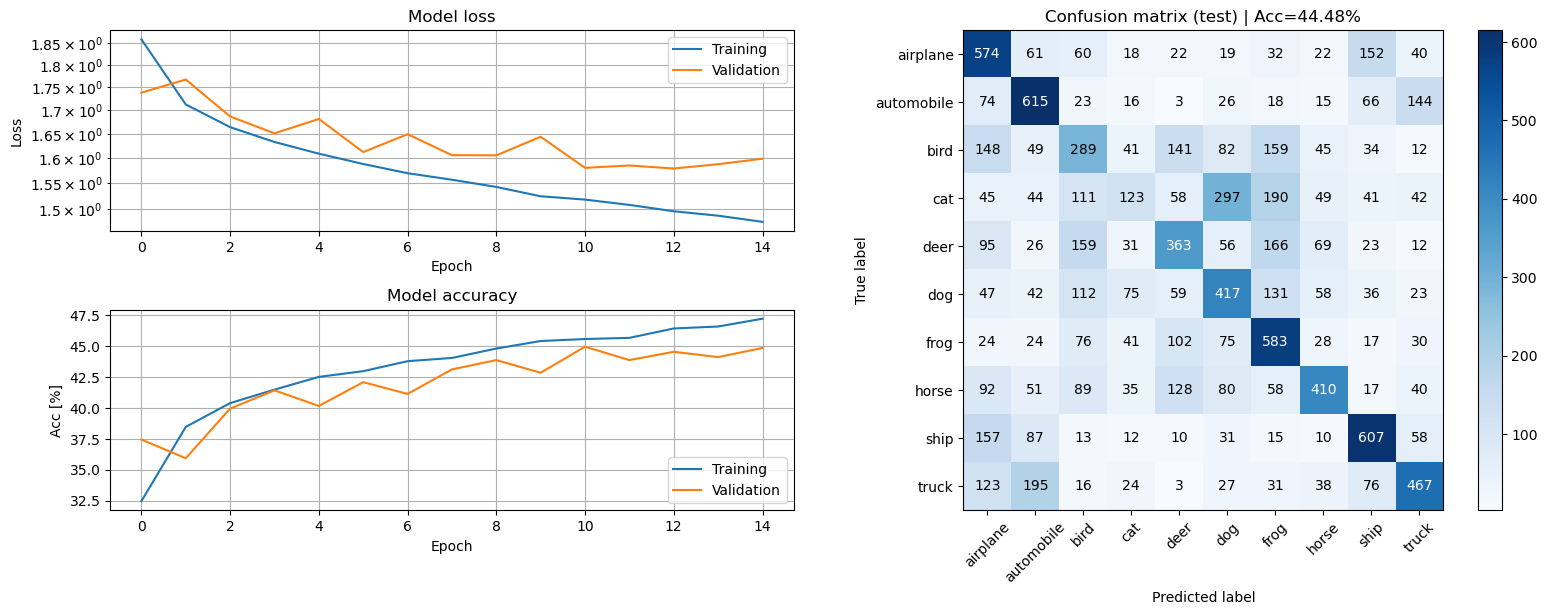

In [10]:
from keras.optimizers import SGD
from keras.models import Model
from keras.layers import Input, Dense, Flatten

def CreateFullyConnectedModel(): 

    x_in = Input(shape=X_train.shape[1:])
    x = Flatten()(x_in)
    
    # --------------------------------------------
    # === Your code here =========================
    # --------------------------------------------
    
    # Hidden layers, using ReLU activation function to avoid vanishing gradient problem
    x = Dense(64, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    
    # Output layer: 10 classes with softmax activation to be able to represent the probabilities for the different classes
    x = Dense(10, activation='softmax')(x)
    
    # ============================================
    
    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the fully connected model
TrainModelAndPlotResults(CreateFullyConnectedModel)

#### **<span style="color:red">Question 2:</span>**
Train a model that achieves above 45% accuracy on the test data. Provide a (short) motivation of your model architecture and briefly discuss the results.

#### **<span style="color:green">Answer:</span>**
* 2 hidden layers using ReLU activation function to avoid vanishing gradient problem
* output layer with 10 nodes and softmax activation function to represent all 10 classes
* Few layers and few nodes to keep costs down

#### **<span style="color:red">Question 3:</span>**
Compare this model to the one you used for the MNIST dataset in the first assignment, in terms of size and test accuracy. Why do you think this dataset is much harder to classify than the MNIST handwritten digits?

#### **<span style="color:green">Answer:</span>**
* Consistent shapes in handwritten digits, every "1" looks alomst the same, but cars can look very different in many different shapes. More complex and diverse structures in the CIFAR10 images.
* More pixels in CIFAR10 dataset images
* More color information increases complexity of CIFAR10 images
* Digits are centered with plain backgrounds, whereas CIFAR10 have complex and busy noicefull image backgrounds of the actual object to classify

### **3. CNN classifier**
We will now move on to a network architecture that is more suited for this problem, the convolutional neural network. The new layers you will use are ```Conv2D``` and ```MaxPooling2D```, which you can find the documentation of here https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D and here https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D.

##### **Creating the CNN model**

A common way to build convolutional neural networks is to create blocks of layers of the form **[convolution - activation - pooling]**, and then stack several of these block to create the full convolution stack. This is often followed by a fully connected network to create the output classes. Use this recipe to build a CNN that acheives at least 62% accuracy on the test data.

*Side note. Although this is a common way to build CNNs, it is be no means the only or even best way. It is a good starting point, but later in part 5 you might want to explore other architectures to acheive even better performance.*

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)                 │ (None, 32, 32, 3)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_6 (Conv2D)                          │ (None, 32, 32, 32)              │               896 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_6 (MaxPooling2D)             │ (None, 10, 10, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_7 (Conv2D)                          │ (None, 10, 10, 64)              │            18,496 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_7 (MaxPooling2D)             │ (None, 3, 3, 64)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_8 (Conv2D)                          │ (None, 3, 3, 128)               │            73,856 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_8 (MaxPooling2D)             │ (None, 1, 1, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ flatten_4 (Flatten)                        │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_10 (Dense)                           │ (None, 128)                     │            16,512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_11 (Dense)                           │ (None, 10)                      │             1,290 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.2705 - loss: 1.9425 - val_accuracy: 0.4930 - val_loss: 1.4074
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5396 - loss: 1.2839 - val_accuracy: 0.5843 - val_loss: 1.1588
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6207 - loss: 1.0668 - val_accuracy: 0.6307 - val_loss: 1.0677
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6725 - loss: 0.9336 - val_accuracy: 0.6704 - val_loss: 0.9636
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7087 - loss: 0.8366 - val_accuracy: 0.6703 - val_loss: 0.9656
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7316 - loss: 0.7593 - val_accuracy: 0.6805 - val_loss: 0.9328
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7554 - loss: 0.6962 - val_accuracy: 0.7086 - val_loss: 0.8527
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7771 - loss: 0.6388 - 

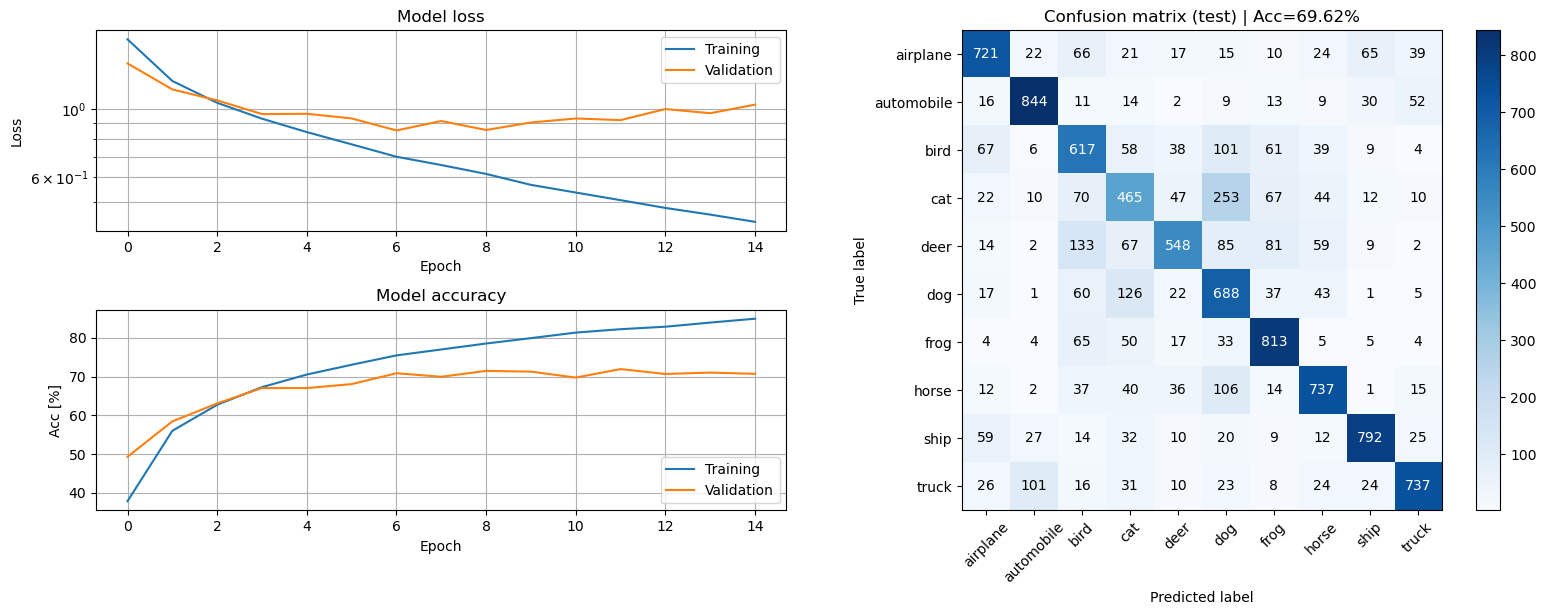

In [12]:
from keras.layers import Conv2D, MaxPooling2D

def CreateCNNModel():

    x_in = Input(shape=X_train.shape[1:])
    
    # --------------------------------------------
    # === Your code here =========================
    # --------------------------------------------

    # FEATURE LEARNING (1-3)
    # 1. Convolutional layers: Feature extraction - Convolutional filters (KERNELS) extract low-level features (edges, corners, etc)
    # 2. Activation function: ReLU is applied to introduce non-linearity
    # 3. Pooling: Downsampling - Reduces spational dimensions (height/width) to retain most important features
    # 3.x Repeat 1, 2, 3
    # CLASSIFICATION (4-6)
    # 4. Flatten: Make into single dimension vector (28x28 --> 1x784)
    # 5. Fully connected: Each node is connected to every node in next layer
    # 6. Softmax output: assign probabilities to each class

    # Common practice in CNN: 3x3 kernel, 3-block structure with 32/64/128 filters on Conv, 2x2 Pooling size

    ### FEATURE LEARNING ###
    ### Block 1
    # Convolution + ReLU activation: the scalar product between the kernel and the corresponding image patch is computed
    x = Conv2D(32, (3,3), activation='relu', strides=1, padding='same')(x_in)
    # Pooling: Downsamples the input along its spatial dimensions (height and width) by taking the 
    # maximum value over an input window (of size defined by pool_size) for each channel of the input.
    x = MaxPooling2D(pool_size=(3,3))(x)

    ### Block 2
    x = Conv2D(64, (3,3), activation='relu', strides=1, padding='same')(x)
    x = MaxPooling2D(pool_size=(3,3))(x)

    ## Block 3
    x = Conv2D(128, (3,3), activation='relu', strides=1, padding='same')(x)
    x = MaxPooling2D(pool_size=(3,3))(x)    
    

    ### CLASSIFICATION ###
    # Flatten
    x = Flatten()(x)
    # Fully connected layer
    x = Dense(128, activation='relu')(x)
    # Softmax output
    x = Dense(10, activation='softmax')(x)


    # padding = valid: will reduce shape according to kernel size
    # padding = same: returns same shape as input (by design)
    # strides = 1: 
    # strides no declared it is thre pooling size

    # OBS: Color information is lost after the first conolutional layer
    
    # ============================================
    
    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the CNN model
TrainModelAndPlotResults(CreateCNNModel)

#### **<span style="color:red">Question 4:</span>**
Train a model that achieves at least 62% test accuracy. Provide a (short) motivation of your model architecture and briefly discuss the results.

#### **<span style="color:green">Answer:</span>**
Common practice in CNN: 3x3 kernel, 3-block structure with 32/64/128 filters on Conv, 2x2 Pooling size. So we started by trying this.
* 3x3 kernel size: Small enough to capture local details, simple enough to keep no. of parameters low
* 32 --> 64 --> 128 filters: Increase feature extraction capacity deeper in the newtork
* 3x3 pooling size: Quickly reduces spatial size

- Higher pooling size: Generalization.
- Higher kernel size: Less detailed feature extraction, increased computational cost because of more parameters

#### **<span style="color:red">Question 5:</span>**
Compare this model with the previous fully connected model. You should find that this one is much more efficient, i.e. achieves higher accuracy with fewer parameters. Explain in your own words how this is possible.

#### **<span style="color:green">Answer:</span>**

In a fully connected (dense) layer, each neuron has a separate weight for every input pixel. This leads to a large number of parameters.
In a convolutional layer, a kernel (or filter) slides across the image, applying the same set of weights to different spatial regions.
Since the same kernel weights are used across the entire input, the number of parameters is significantly reduced.

### **4. Regularization**

#### **4.1 Dropout**
You have probably seen that your CNN model overfits the training data. One way to prevent this is to add ```Dropout``` layers to the model, that randomly "drops" hidden nodes each training-iteration by setting their output to zero. Thus the model cannot rely on a small set of very good hidden features, but must instead learns to use different sets of hidden features each time. Dropout layers are usually added after the pooling layers in the convolution part of the model, or after activations in the fully connected part of the model.

*Side note. In the next assignment you will work with Ensemble models, a way to use the output from several individual models to achieve higher performance than each model can achieve on its own. One way to interpret Dropout is that each random selection of nodes is a separate model that is trained only on the current iteration. The final output is then the average of outputs from all the individual models. In other words, Dropout can be seen as a way to build ensembling directly into the network, without having to train several models explicitly.*

Extend your previous model with the Dropout layer and test the new performance.

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)                 │ (None, 32, 32, 3)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_9 (Conv2D)                          │ (None, 32, 32, 32)              │               896 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_9 (MaxPooling2D)             │ (None, 10, 10, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 10, 10, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_10 (Conv2D)                         │ (None, 10, 10, 64)              │            18,496 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_10 (MaxPooling2D)            │ (None, 3, 3, 64)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_1 (Dropout)                        │ (None, 3, 3, 64)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_11 (Conv2D)                         │ (None, 3, 3, 128)               │            73,856 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_11 (MaxPooling2D)            │ (None, 1, 1, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_2 (Dropout)                        │ (None, 1, 1, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ flatten_5 (Flatten)                        │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_12 (Dense)                           │ (None, 128)                     │            16,512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_3 (Dropout)                        │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_13 (Dense)                           │ (None, 10)                      │             1,290 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.1752 - loss: 2.1506 - val_accuracy: 0.3878 - val_loss: 1.6809
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.3566 - loss: 1.7188 - val_accuracy: 0.4576 - val_loss: 1.5213
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4231 - loss: 1.5756 - val_accuracy: 0.5153 - val_loss: 1.3658
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4533 - loss: 1.4996 - val_accuracy: 0.4974 - val_loss: 1.3697
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4729 - loss: 1.4390 - val_accuracy: 0.5273 - val_loss: 1.3535
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4884 - loss: 1.4123 - val_accuracy: 0.5549 - val_loss: 1.2759
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5063 - loss: 1.3738 - val_accuracy: 0.5650 - val_loss: 1.2337
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.5176 - loss: 1.340

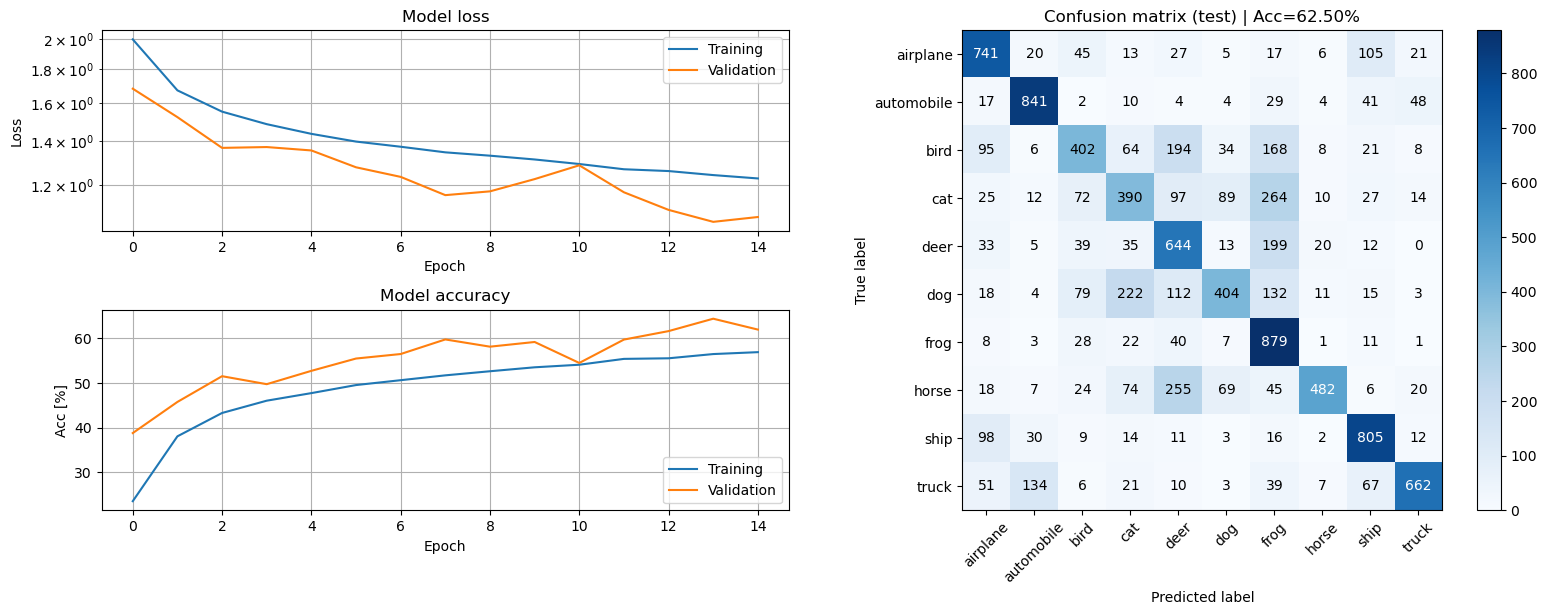

In [14]:
from keras.layers import Dropout

def CreateDropoutModel():

    x_in = Input(shape=X_train.shape[1:])
    
    # --------------------------------------------
    # === Your code here =========================
    # --------------------------------------------

    ### Block 1
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x_in)
    x = MaxPooling2D(pool_size=(3,3))(x)
    x = Dropout(0.3)(x)  # Dropout after pooling

    ### Block 2
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(3,3))(x)
    x = Dropout(0.3)(x)  # Dropout after pooling

    ### Block 3
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(3,3))(x)
    x = Dropout(0.3)(x)  # Dropout after pooling

    ### CLASSIFICATION
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)  # Dropout in fully connected part
    x = Dense(10, activation='softmax')(x)

    # ============================================
    
    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the Dropout model
TrainModelAndPlotResults(CreateDropoutModel)

#### **<span style="color:red">Question 6:</span>**
Compare this model and the previous in terms of the training accuracy, validation accuracy, and test accuracy. Explain the similarities and differences (remember that the only difference between the models should be the addition of Dropout layers).

Hint: what does the dropout layer do at test time?

#### **<span style="color:green">Answer:</span>**
For the dropout model, we can see that we do not have higher validation and test accuracy (although not much worse), but the difference between the training and validation/test data is much lower, indicating that we have less overfitting. This is reasonable, dropout has the purpose of preventing overfitting. 

#### **4.2 Batch normalization**
The final layer we will explore is ```BatchNormalization```. As the name suggests, this layer normalizes the data in each batch to have a specific mean and standard deviation, which is learned during training. The reason for this is quite complicated (and still debated among the experts), but suffice to say that it helps the optimization converge faster which means we get higher performance in fewer epochs. The normalization is done separatly for each feature, i.e. the statistics are calculated accross the batch dimension of the input data. The equations for batch-normalizing one feature are the following, where $N$ is the batch size, $x$ the input features, and $y$ the normalized output features:

$$ \mu = \frac{1}{N} \sum_{i=0}^{N}x_i,\;\;\;\; \sigma^2 = \frac{1}{N} \sum_{i=0}^{N}(x_i - \mu)^2 $$

$$ \hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} $$

$$ y_i = \gamma \hat{x}_i + \beta $$

At first glance this might look intimidating, but all it means is that we begin by scaling and shifting the data to have mean $\mu=0$ and standard deviation $\sigma=1$. After this we use the learnable parameters $\gamma$ and $\beta$ to decide the width and center of the final distribution. $\epsilon$ is a small constant value that prevents the denominator from being zero.

In addition to learning the parameters $\gamma$ and $\beta$ by gradient decent just like the weights, Batch Normalization also keeps track of the running average of minibatch statistics $\mu$ and $\sigma$. These averages are used to normalize the test data. We can tune the rate at which the running averages are updated with the *momentum* parameter of the BatchNormalization layer. A large momentum means that the statistics converge more slowly and therefore requires more updates before it represents the data. A low momentum, on the other hand, adapts to the data more quickly but might lead to unstable behaviour if the latest minibatches are not representative of the whole dataset. For this test we recommend a momentum of 0.75, but you probably want to change this when you design a larger network in Section 5.

The batch normalization layer should be added after the hidden layer linear transformation, but before the nonlinear activation. This means that we cannot specify the activation funciton in the ```Conv2D``` or ```Dense``` if we want to batch-normalize the output. We therefore need to use the ```Activation``` layer to add a separate activation to the network stack after batch normalization. For example, the convolution block will now look like **[conv - batchnorm - activation - pooling]**.

Extend your previous model with batch normalization, both in the convolution and fully connected part of the model.

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)                 │ (None, 32, 32, 3)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_18 (Conv2D)                         │ (None, 32, 32, 32)              │               896 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_4 (BatchNormalization) │ (None, 32, 32, 32)              │               128 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_4 (Activation)                  │ (None, 32, 32, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_18 (MaxPooling2D)            │ (None, 10, 10, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_19 (Conv2D)                         │ (None, 10, 10, 64)              │            18,496 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_5 (BatchNormalization) │ (None, 10, 10, 64)              │               256 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_5 (Activation)                  │ (None, 10, 10, 64)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_19 (MaxPooling2D)            │ (None, 3, 3, 64)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_20 (Conv2D)                         │ (None, 3, 3, 128)               │            73,856 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_6 (BatchNormalization) │ (None, 3, 3, 128)               │               512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_6 (Activation)                  │ (None, 3, 3, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_20 (MaxPooling2D)            │ (None, 1, 1, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ flatten_8 (Flatten)                        │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_18 (Dense)                           │ (None, 128)                     │            16,512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_7 (BatchNormalization) │ (None, 128)                     │               512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_7 (Activation)                  │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_19 (Dense)                           │ (None, 10)                      │             1,290 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 112,458 (439.29 KB)

 Trainable params: 111,754 (436.54 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.4572 - loss: 1.5113 - val_accuracy: 0.6032 - val_loss: 1.1140
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6427 - loss: 1.0104 - val_accuracy: 0.6757 - val_loss: 0.9325
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7022 - loss: 0.8481 - val_accuracy: 0.6965 - val_loss: 0.8558
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7322 - loss: 0.7576 - val_accuracy: 0.7045 - val_loss: 0.8489
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7577 - loss: 0.6849 - val_accuracy: 0.7292 - val_loss: 0.7835
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7840 - loss: 0.6156 - val_accuracy: 0.7258 - val_loss: 0.8016
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8011 - loss: 0.5678 - val_accuracy: 0.7436 - val_loss: 0.7634
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8107 - 

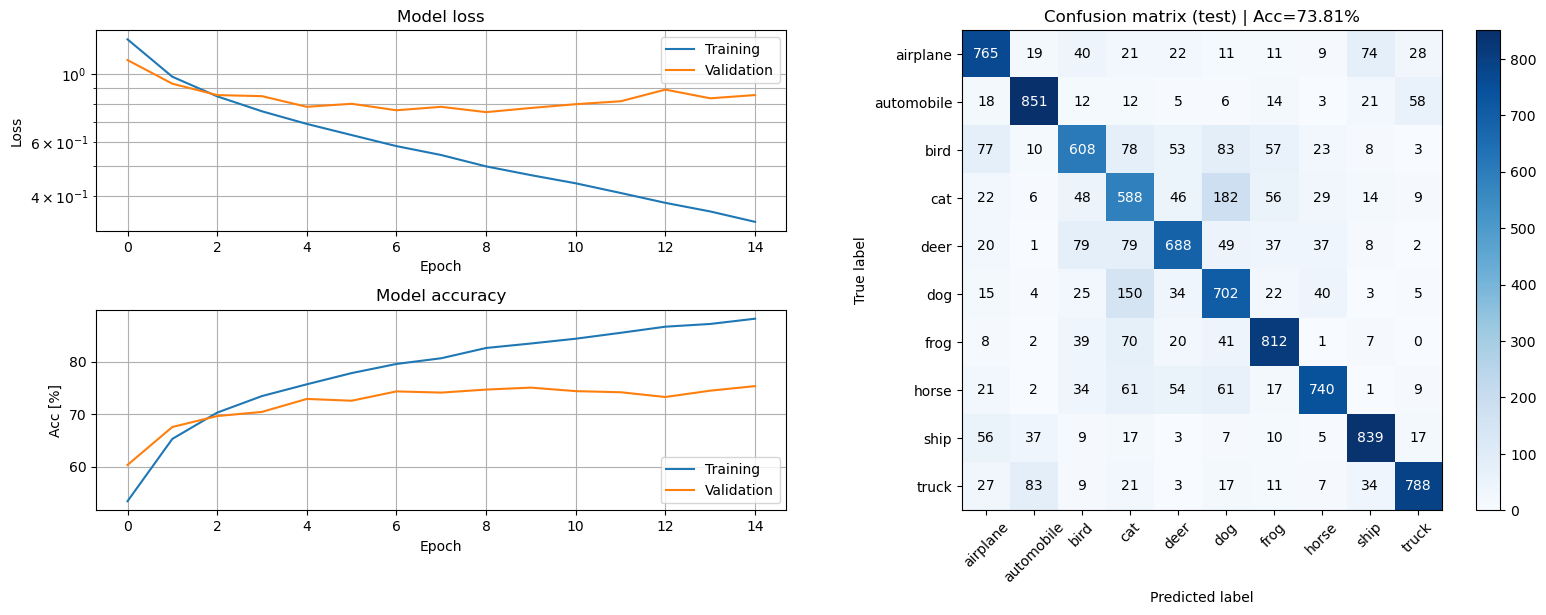

In [18]:
from keras.layers import BatchNormalization, Activation

def CreateBatchNormModel():
    
    x_in = Input(shape=X_train.shape[1:])
    
    # --------------------------------------------
    # === Your code here =========================
    # --------------------------------------------

    ### Block 1
    x = Conv2D(32, (3,3), padding='same')(x_in)
    x = BatchNormalization(momentum=0.75)(x)  # Batch Normalization after Conv
    x = Activation('relu')(x)  # Separate Activation layer
    x = MaxPooling2D(pool_size=(3,3))(x)

    ### Block 2
    x = Conv2D(64, (3,3), padding='same')(x)
    x = BatchNormalization(momentum=0.75)(x)  
    x = Activation('relu')(x)  
    x = MaxPooling2D(pool_size=(3,3))(x)

    ### Block 3
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization(momentum=0.75)(x)  
    x = Activation('relu')(x) 
    x = MaxPooling2D(pool_size=(3,3))(x)

    ### CLASSIFICATION
    x = Flatten()(x)
    x = Dense(128)(x)
    x = BatchNormalization(momentum=0.75)(x)  
    x = Activation('relu')(x) 
    x = Dense(10, activation='softmax')(x)
    
    # ============================================
    
    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the BatchNorm model
TrainModelAndPlotResults(CreateBatchNormModel)

#### **<span style="color:red">Question 7:</span>**
When using BatchNorm one must take care to select a good minibatch size. Describe what problems might arise if:

1. The minibatch size is too small.
2. The minibatch size is too large.

You can reason about this given the description of BatchNorm above, or you can search for the information in other sources. Do not forget to provide links to the sources if you do!

#### **<span style="color:green">Answer:</span>**
If the minibatch size is too small:
* Unstable mean and variance: the mean and variance are computed from only a few samples, making them senstive to noise.
* Poor generalization: Since each batch can be different, the model might struggle to learn stable feature distributions.
* Ineffective normalization: small batches may not be varied enough, which might make batch normalization ineffective, especially since the mean and variance may be unstable.

If the minibatch size is too large:
* Slow training: large batches requires more memory which reduces training and limites hardware efficiency 
* Reduced generalization: large batch sizes can lead to poor generalization because they produce smoother, less noisy updates, which can make the model overfit to high-confidence solutions
* Inefficient updates: Gradient updates become less frequent, making training less dynamic

Source: ChatGPT
Source: Stack overflow https://stackoverflow.com/questions/46654424/how-to-calculate-optimal-batch-size

### **5. Putting it all together**
We now want you to create your own model based on what you have learned. We want you to experiment and see what works and what doesn't, so don't go crazy with the number of epochs until you think you have something that works.

To pass this assignment, we want you to acheive **75%** accuracy on the test data in no more than **25 epochs**. This is possible using the layers and techniques we have explored in this notebook, but you are free to use any other methods that we didn't cover. (You are obviously not allowed to cheat, for example by training on the test data.)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)                │ (None, 32, 32, 3)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_24 (Conv2D)                         │ (None, 32, 32, 32)              │               896 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_12                     │ (None, 32, 32, 32)              │               128 │
│ (BatchNormalization)                       │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_12 (Activation)                 │ (None, 32, 32, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_24 (MaxPooling2D)            │ (None, 16, 16, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_8 (Dropout)                        │ (None, 16, 16, 32)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_25 (Conv2D)                         │ (None, 16, 16, 64)              │            18,496 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_13                     │ (None, 16, 16, 64)              │               256 │
│ (BatchNormalization)                       │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_13 (Activation)                 │ (None, 16, 16, 64)              │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_25 (MaxPooling2D)            │ (None, 8, 8, 64)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_9 (Dropout)                        │ (None, 8, 8, 64)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d_26 (Conv2D)                         │ (None, 8, 8, 128)               │            73,856 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ batch_normalization_14                     │ (None, 8, 8, 128)               │               512 │
│ (BatchNormalization)                       │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ activation_14 (Activation)                 │ (None, 8, 8, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d_26 (MaxPooling2D)            │ (None, 4, 4, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout_10 (Dropout)                       │ (None, 4, 4, 128)               │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ flatten_10 (Flatten)                       │ (None, 2048)                    │                 0 │
├────────────────────────────────────────────┼───────────────

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - accuracy: 0.3594 - loss: 1.7825 - val_accuracy: 0.4756 - val_loss: 1.4649
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.5127 - loss: 1.3425 - val_accuracy: 0.5395 - val_loss: 1.3265
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.5675 - loss: 1.1956 - val_accuracy: 0.6463 - val_loss: 0.9792
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.6148 - loss: 1.0838 - val_accuracy: 0.6525 - val_loss: 0.9742
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.6423 - loss: 1.0112 - val_accuracy: 0.6745 - val_loss: 0.9096
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6553 - loss: 0.9697 - val_accuracy: 0.6917 - val_loss: 0.8819
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6715 - loss: 0.9291 - val_accuracy: 0.6741 - val_loss: 0.9365
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.6816 -

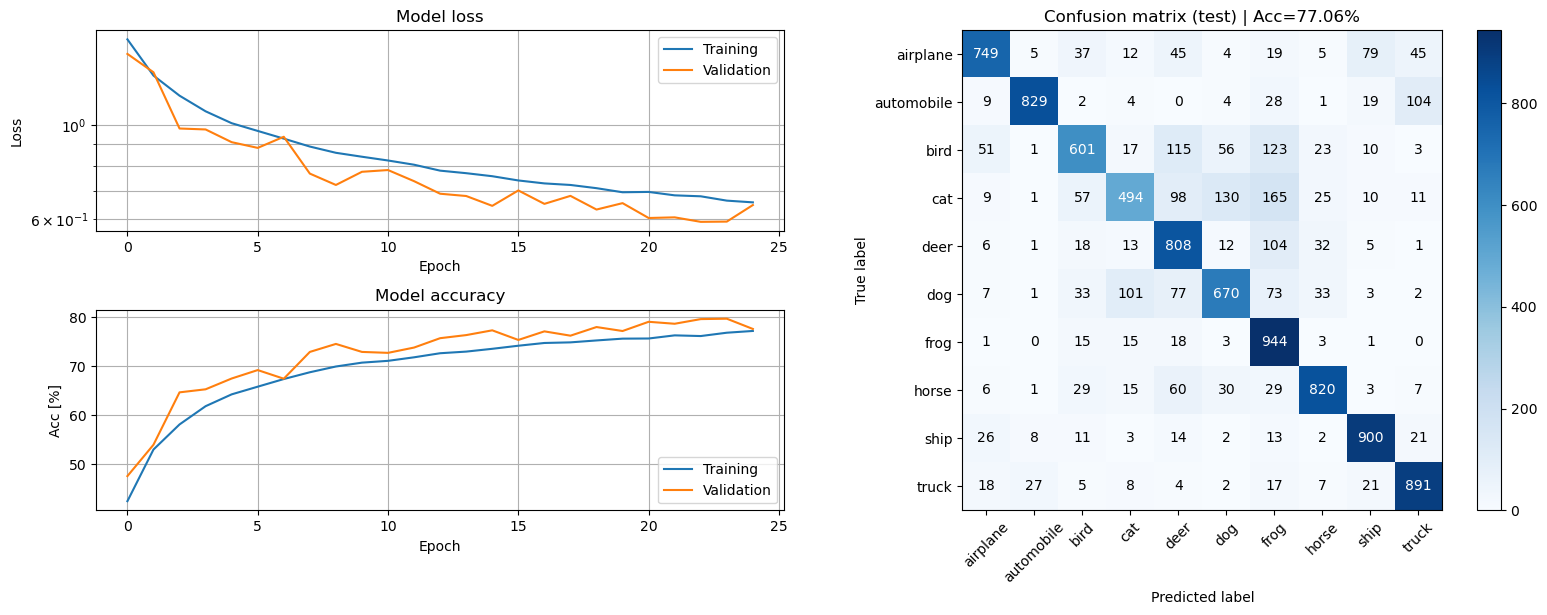

In [20]:
def CreateFinalModel():

    x_in = Input(shape=X_train.shape[1:])
    
    # --------------------------------------------
    # === Your code here =========================
    # --------------------------------------------

    ### Block 1
    x = Conv2D(32, (3,3), padding='same')(x_in) # no activation
    x = BatchNormalization(momentum=0.75)(x)  # Batch Normalization after Conv
    x = Activation('relu')(x)  # Separate Activation layer
    x = MaxPooling2D(pool_size=(2,2))(x)
    x = Dropout(0.3)(x)  # Dropout after pooling


    ### Block 2
    x = Conv2D(64, (3,3), padding='same')(x) 
    x = BatchNormalization(momentum=0.75)(x)  
    x = Activation('relu')(x)  
    x = MaxPooling2D(pool_size=(2,2))(x)
    x = Dropout(0.3)(x)

    ### Block 3
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization(momentum=0.75)(x)  
    x = Activation('relu')(x) 
    x = MaxPooling2D(pool_size=(2,2))(x)
    x = Dropout(0.3)(x)

    ### CLASSIFICATION
    x = Flatten()(x)
    x = Dense(128)(x) # no activation
    x = BatchNormalization(momentum=0.75)(x)  
    x = Activation('relu')(x) 
    x = Dropout(0.3)(x)
    x = Dense(10, activation='softmax')(x)
    
    # ============================================
    
    model = Model(inputs=x_in, outputs=x)
    return model

# Run training on the final model
TrainModelAndPlotResults(CreateFinalModel, epochs=25)

#### **<span style="color:red">Question 8:</span>**
Design and train a model that achieves at least 75% test accuracy in at most 25 epochs. Explain your model architecture and motivate the design choices you have made.

#### **<span style="color:green">Answer:</span>**
* Conv2D (32, 64, 128 filters, kernel size (3,3)) → Extracts spatial features at increasing levels of complexity.
* Padding='same' → Keeps the output size consistent, preventing loss of edge information.
* BatchNormalization → Stabilizes training by normalizing feature maps, improving convergence.
* ReLU Activation → Introduced separately after BatchNorm to prevent vanishing gradients.
* MaxPooling2D (2x2) → Reduces spatial dimensions, making computation more efficient while retaining important features.
* Dropout (0.3) → Prevents overfitting by randomly deactivating 30% of neurons, adding regularization.

---

### **Want some extra challenge?**
For those of you that want to get creative, here are some things to look into. But note that we don't have the answers here. Any of these might improve the performance, or might not, or it might only work in combination with each other. This is up to you to figure out. This is how deep learning research often happens, trying things in a smart way to see what works best.
* Tweak or change the optimizer or training parameters.
* Tweak the filter parameters, such as numbers and sizes of filters.
* Use other activation functions.
* Add L1/L2 regularization (see https://www.tensorflow.org/api_docs/python/tf/keras/regularizers)
* Include layers that we did not cover here (see https://www.tensorflow.org/api_docs/python/tf/keras/layers). For example, our best model uses the global pooling layers.
* Take inspiration from some well-known architectures, such as ResNet or VGG16. (But don't just copy-paste those architectures. For one, what's the fun in that? Also, they take a long time to train, you will not have time.)
* Use explicit model ensembing (training multiple models that vote on or average the outputs - this will also take a lot of time.)
* Use data augmentation to create a larger training set (see https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator).